# Smoking & Drinking Detection — **Finalized YOLOv8n Model**

This notebook contains **only the finished model**: the tuned **YOLOv8n** loaded from your
`yolov8n_best.pt` (trained 80 epochs on the full dataset with the winning hyperparameters), plus the
locked-in best parameters. No tuning, no training, no dataset prep — just load the model and detect.

**Classes:** `smoking (0)`, `drinking (1)` &nbsp;|&nbsp; **Input size:** 640×640

### Finalized best hyperparameters (for the record)
| Parameter | Value |
|---|---|
| model | yolov8n |
| lr0 | 0.001 |
| optimizer | AdamW |
| cos_lr | True |
| close_mosaic | 10 |
| imgsz | 640 |
| epochs | 80 |
| batch | 16 |
| seed | 42 |
| selected trial | t3_lr001_adamw |

## 1 · Setup

In [ ]:
%pip -q install "ultralytics>=8.3.0" pyyaml matplotlib >/dev/null 2>&1

from pathlib import Path
import yaml
import matplotlib.pyplot as plt
import torch
from ultralytics import YOLO

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Device: Tesla T4


## 2 · Load the finalized weights (upload via the left Files panel)

Open the **Files** panel on the left of Colab (the folder icon), and **drag your files into
`/content`** — no Drive needed. You can upload either:

* the **zip** you downloaded (`m4_yolov8n_best_weights.zip`) — it will be **unzipped automatically**, or
* the loose **`yolov8n_best.pt`** (and optionally `best_hyperparameters.yaml`).

Then run the cell below. Tip: if you upload while a cell is running, re-run this cell afterwards.

In [ ]:
from pathlib import Path
import zipfile

CONTENT = Path("/content")

# 1) If a zip bundle was uploaded to /content, unzip it (looks for one containing a .pt)
for z in sorted(CONTENT.glob("*.zip")):
    try:
        with zipfile.ZipFile(z) as zf:
            if any(n.lower().endswith(".pt") for n in zf.namelist()):
                zf.extractall(CONTENT)
                print("Unzipped:", z.name)
    except zipfile.BadZipFile:
        print("Skipped (not a valid zip):", z.name)

# 2) locate the weights (.pt) anywhere under /content
def _find(pattern):
    hits = [p for p in CONTENT.rglob(pattern) if p.is_file()]
    return sorted(hits, key=lambda p: len(str(p)))[0] if hits else None

weights = _find("yolov8n_best.pt") or _find("best.pt") or _find("*.pt")
assert weights is not None, (
    "No .pt found in /content. Drag yolov8n_best.pt (or the zip) into the left Files panel, "
    "then re-run this cell.")

model = YOLO(str(weights))
print("Loaded finalized model from:", weights)
print("Classes:", model.names)
model.info()

Unzipped: m4_yolov8n_best_weights.zip
Loaded finalized model from: /content/yolov8n_best.pt
Classes: {0: 'smoking', 1: 'drinking'}
Model summary: 130 layers, 3,011,238 parameters, 0 gradients, 8.2 GFLOPs


(130, 3011238, 0, 8.192768)

## 3 · Confirm the finalized best parameters
Reads `best_hyperparameters.yaml` if you uploaded it (or if it came out of the zip); otherwise shows
the locked-in values.

In [ ]:
import yaml

yml = _find("best_hyperparameters.yaml") or _find("*hyperparameters*.yaml")
if yml is not None:
    FINAL_PARAMS = yaml.safe_load(Path(yml).read_text())
    print("Loaded params from:", yml)
    print("\nLoaded hyperparameters:")
    for k, v in FINAL_PARAMS.items():
        print(f"  {k:16s}: {v}")

Loaded params from: /content/best_hyperparameters.yaml

Loaded hyperparameters:
  model           : yolov8n
  imgsz           : 640
  epochs          : 80
  batch           : 16
  seed            : 42
  selected_trial  : t3_lr001_adamw
  lr0             : 0.001
  optimizer       : AdamW
  cos_lr          : True
  close_mosaic    : 10


## 4 · Detect — run the model on your images
Upload your test image(s) into `/content` via the left **Files** panel, then run this cell
(or set `SOURCE` to a specific image/folder path).

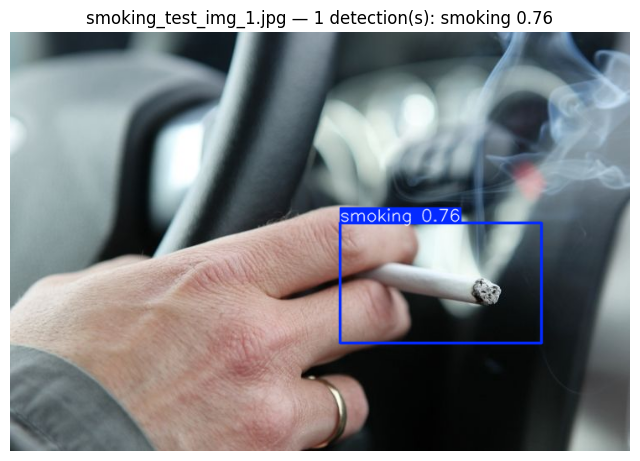

In [ ]:
SOURCE = None          # e.g. "/content/my_photo.jpg" or "/content/test_pics"
CONF   = 0.25          # confidence threshold
_EXTS  = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

if SOURCE:
    p = Path(SOURCE)
    paths = [p] if p.is_file() else sorted(q for q in p.glob("*.*") if q.suffix.lower() in _EXTS)
else:
    # auto-collect images uploaded to /content (skip Colab's sample_data + any run outputs)
    paths = sorted(q for q in CONTENT.rglob("*")
                   if q.suffix.lower() in _EXTS and "sample_data" not in str(q)
                   and "runs" not in str(q) and "predictions" not in str(q))

assert paths, ("No images found in /content. Drag image(s) into the left Files panel, then re-run.")

for img in paths:
    res = model.predict(source=str(img), imgsz=640, conf=CONF, device=DEVICE, verbose=False)[0]
    annotated = res.plot()[:, :, ::-1]     # BGR → RGB
    labels = [f"{model.names[int(b.cls)]} {float(b.conf):.2f}" for b in res.boxes]
    plt.figure(figsize=(8, 8)); plt.imshow(annotated); plt.axis("off")
    plt.title(f"{img.name} — {len(res.boxes)} detection(s): " + (", ".join(labels) if labels else "none"))
    plt.show()

## 5 · (Optional) Save annotated results
Writes annotated images to a folder and, on Colab, downloads them.

In [ ]:
OUT = Path("/content/predictions"); OUT.mkdir(exist_ok=True)
import cv2
saved = []
for img in paths:
    res = model.predict(source=str(img), imgsz=640, conf=CONF, device=DEVICE, verbose=False)[0]
    dst = OUT / f"pred_{Path(img).name}"
    cv2.imwrite(str(dst), res.plot()); saved.append(dst)
print("Saved annotated images to:", OUT)
for s in saved: print("  ", s)
# (You can also download them from the left Files panel: /content/predictions)

Saved annotated images to: /content/predictions
   /content/predictions/pred_smoking_test_img_1.jpg


## 6 · Detect on video — **real-time live playback**

Upload your test video into `/content` via the left **Files** panel, then run this cell
(or set `VIDEO_SOURCE` to a specific video path).

Instead of writing a file to download, this plays the video **live inside the notebook**:
each frame is run through the model and the bounding boxes appear **in progression as the
video plays**. All the temporal-consistency smoothing is kept, so `drinking` / `smoking`
boxes are only drawn once the action is stable across the sliding time-window.

Processing video: 9531460-uhd_4096_2160_25fps.mp4
fps=25.0  ->  window=20f  on>=12  off<=5
Playing live — boxes are drawn as the model confirms each action…



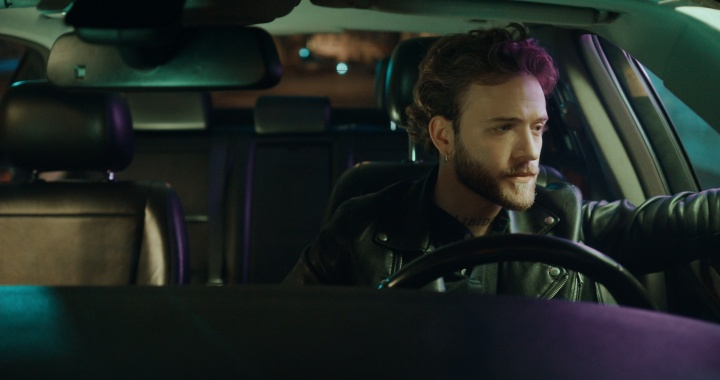


Done. Frames processed: 1455

Confirmed events:
  frame   40  t= 1.60s  smoking   START
  frame   60  t= 2.40s  smoking   END
  frame   80  t= 3.20s  smoking   START
  frame  397  t=15.88s  smoking   END
  frame  537  t=21.48s  smoking   START
  frame  675  t=27.00s  smoking   END
  frame 1047  t=41.88s  smoking   START
  frame 1077  t=43.08s  smoking   END
  frame 1132  t=45.28s  smoking   START
  frame 1179  t=47.16s  smoking   END


In [ ]:
# ============================================================================
#  Detect on video — REAL-TIME LIVE PLAYBACK (temporal-consistency version).
#  Runs the model per frame and streams each annotated frame straight into the
#  notebook output, so the bounding boxes appear in progression AS THE VIDEO
#  PLAYS. No file is written and there is nothing to download.
#  Uses the `model` and `DEVICE` already loaded above.
# ============================================================================
from pathlib import Path
from collections import deque, defaultdict
from IPython.display import display, Image, clear_output
import cv2, time

CONTENT = Path("/content")
VIDEO_SOURCE = None            # e.g. "/content/output.avi"; None = auto-find

# ---- playback options ----
REALTIME = True               # cap playback to the video's real speed (never faster)
STRIDE   = 1                  # process every Nth frame (2/3 = smoother on slow CPUs)
MAX_WIDTH = 720               # downscale display for smoother streaming (px); None=off

CONF_PER_CLASS = {
    "smoking":  0.40,   # loose: catch more
    "drinking": 0.50,   # strict: kill the flicker
}

WINDOW_SEC = 0.80       # longer window = more evidence before confirming
ON_FRAC    = 0.60       # need 60% of the window to be hits (was 0.55)
OFF_FRAC   = 0.25       # (was 0.20)


def _find_video():
    if VIDEO_SOURCE:
        p = Path(VIDEO_SOURCE)
        assert p.is_file(), f"Video not found: {p}"
        return p
    exts = (".mp4", ".avi", ".mov", ".mkv")
    vids = sorted(q for q in CONTENT.rglob("*")
                  if q.suffix.lower() in exts and "sample_data" not in str(q)
                  and "runs" not in str(q) and "predictions" not in str(q))
    assert vids, "No video found in /content. Upload one via the Files panel."
    return vids[0]


class TemporalVoter:
    """Sliding-window majority vote + hysteresis, per class.
    Feed it the set of class names detected each frame; returns the set of
    currently CONFIRMED (ON) classes. Short flickers never reach on_hits."""
    def __init__(self, window, on_hits, off_hits):
        self.on_hits, self.off_hits = on_hits, off_hits
        self.hist  = defaultdict(lambda: deque(maxlen=window))
        self.state = defaultdict(bool)

    def update(self, present):
        for c in set(self.hist) | set(present):
            self.hist[c].append(1 if c in present else 0)
            hits = sum(self.hist[c])
            if not self.state[c] and hits >= self.on_hits:
                self.state[c] = True
            elif self.state[c] and hits <= self.off_hits:
                self.state[c] = False
        return {c for c, on in self.state.items() if on}


def run_video_live(video_path):
    cap    = cv2.VideoCapture(str(video_path))
    fps    = cap.get(cv2.CAP_PROP_FPS) or 25

    # time-based settings -> frame counts using THIS video's fps
    window   = max(1, round(WINDOW_SEC * fps))
    on_hits  = max(1, round(window * ON_FRAC))
    off_hits = max(0, round(window * OFF_FRAC))
    print(f"fps={fps:.1f}  ->  window={window}f  on>={on_hits}  off<={off_hits}")
    print("Playing live — boxes are drawn as the model confirms each action…\n")

    voter = TemporalVoter(window, on_hits, off_hits)
    last_box = {}                     # <-- add this: cname -> (cf, x1,y1,x2,y2)
    names = model.names                       # {0:'smoking', 1:'drinking'}
    events, prev_confirmed, frame_idx = [], set(), 0

    handle       = None                       # live, in-place display handle
    frame_interval = STRIDE / fps
    t_start      = time.time()

    try:
        while True:
            ok, frame = cap.read()
            if not ok:
                break

            # optional frame-skip for smoother playback on slow hardware
            if STRIDE > 1 and (frame_idx % STRIDE):
                frame_idx += 1
                continue

            # 1) raw per-frame detections from the loaded model
            res = model.track(frame, imgsz=768, conf=0.15, iou=0.6,
                      persist=True, tracker="bytetrack.yaml",
                      device=DEVICE, verbose=False)[0]
            raw = []
            for b in res.boxes:
                cname = names[int(b.cls)]
                cf    = float(b.conf)
                if cf < CONF_PER_CLASS.get(cname, CONF):     # per-class conf floor
                    continue
                raw.append((cname, cf, b.xyxy[0].cpu().numpy()))

            # 2) temporal vote
            confirmed = voter.update({c for c, _, _ in raw})

            # 3) log ON/OFF transitions as events
            for c in confirmed - prev_confirmed:
                events.append((frame_idx, frame_idx / fps, c, "START"))
            for c in prev_confirmed - confirmed:
                events.append((frame_idx, frame_idx / fps, c, "END"))
            prev_confirmed = confirmed

           # 4) draw only CONFIRMED classes (flicker is suppressed here)
            BOX_THICK   = 6      # box border thickness (was 2)
            FONT_SCALE  = 2.0    # label size (was 0.6)
            FONT_THICK  = 2      # label stroke thickness
            # 4) draw only CONFIRMED classes, reusing last box on a momentary miss
            raw_by_cls = {c: (cf, xy) for c, cf, xy in raw}
            for cname in confirmed:
                if cname in raw_by_cls:                 # detected this frame
                    cf, (x1, y1, x2, y2) = raw_by_cls[cname]
                    last_box[cname] = (cf, x1, y1, x2, y2)
                elif cname in last_box:                 # missed this frame -> reuse
                    cf, x1, y1, x2, y2 = last_box[cname]
                else:
                    continue
                color = (0, 0, 255) if cname == "drinking" else (0, 165, 255)
                x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 4)
                cv2.putText(frame, f"{cname} {cf:.2f}", (x1 + 2, max(y1, 20)),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2,
                            cv2.LINE_AA)
            # 5) stream this frame into the notebook (in-place, no download)
            show = frame
            if MAX_WIDTH and frame.shape[1] > MAX_WIDTH:
                scale = MAX_WIDTH / frame.shape[1]
                show = cv2.resize(frame, None, fx=scale, fy=scale,
                                  interpolation=cv2.INTER_AREA)
            ok_enc, jpg = cv2.imencode(".jpg", show)
            if ok_enc:
                img = Image(data=jpg.tobytes())
                if handle is None:
                    handle = display(img, display_id=True)   # first frame
                else:
                    handle.update(img)                       # update in place

            # 6) pace to real time (only ever slows down, never speeds up)
            if REALTIME:
                ahead = (t_start + (frame_idx + 1) / fps) - time.time()
                if ahead > 0:
                    time.sleep(ahead)

            frame_idx += 1
    except KeyboardInterrupt:
        print("\nStopped by user.")
    finally:
        cap.release()

    print(f"\nDone. Frames processed: {frame_idx}\n\nConfirmed events:")
    if not events:
        print("  (none - all detections were momentary and got filtered out)")
    for fi, t, c, kind in events:
        print(f"  frame {fi:4d}  t={t:5.2f}s  {c:9s} {kind}")


video_path = _find_video()
print(f"Processing video: {video_path.name}")
run_video_live(video_path)

### That's it — no download step

The cell above plays the annotated video **live in the output**, drawing boxes in
progression as it processes each frame, then prints the confirmed `START` / `END`
events at the end. Nothing is written to disk.

**Tips**
* On CPU, per-frame inference can be slower than real time — playback simply runs at
  inference speed (the `REALTIME` cap only *slows* fast playback, it never speeds it up).
* For smoother playback on slow hardware, set `STRIDE = 2` or `3` to process every
  Nth frame, and/or lower `MAX_WIDTH`.